In [1]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd
import numpy as np

# https://pypi.org/project/era5cli/

CPU times: user 1.44 s, sys: 1.58 s, total: 3.02 s
Wall time: 1 s


In [2]:
import xarray as xr
ds = xr.open_dataset("../data/data_stream-oper_stepType-instant.nc", engine='h5netcdf')

lat = ds['latitude'].values
lon = ds['longitude'].values

# Coordinates of interest
lat_point = 45.6667
lon_point = -119.6667

# Find the closest indices
lat_idx = (np.abs(lat - lat_point)).argmin() + 1
lon_idx = (np.abs(lon - lon_point)).argmin() + 1

# Extract data at the closest point
data_at_point = ds.isel(latitude=lat_idx, longitude=lon_idx)


In [3]:
# Project imports
from sutton import (
    Params,
    thomas,
    our_central_difference,
    integrate_T_implicit,
    integrate_H2O_implicit,
    stability,
    saturation_vapor_pressure,
    vapor_concentration_RH,
)

In [4]:
# def get_lm(k, h, z, option = 'kz'):
#     """
#     mixing length options
#     """
#     d = 2/3*h
    
#     if option != 'kz':
#         zo = 0.005
#         lm = k*(z + zo)
#     else:
#         a = 1
#         lm = k*z   
#         lm[z < a*(h - d)] = k*a*h/3 
#     return lm


### Boundary conditions from Rao et al (1974)

In [5]:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

cp_air  = 1005.0     # J kg^-1 K^-1
rho_air = 1.20       # kg m^-3

Lv      = 2.43e6     # J kg^-1
Lv_g    = 2430.0  # J g^-1  (~30 °C)


mcal_to_J = 4.184e-3  # 1 mcal = 4.184e-3 J
cm2_to_m2 = 1e-4      # 1 cm² = 1e-4 m²
H01_mcal_cm2_s = 8.5  # Given value in mcal/cm²/s

# Convert to SI units (W/m²)
H_f = H01_mcal_cm2_s * mcal_to_J / cm2_to_m2
LE_f = 0

Q_f = 6.34   # g m3

ustar_f = 0.14

RH_c = 60 # relative humidity


# immediately downwind of transition
H_c0 = - 0.6 * rho_air * cp_air
LE_c0 = rho_air * cp_air


H_c2 = - 0.2 * rho_air * cp_air
LE_c2 = 0.44*rho_air * cp_air

H_c20 = - 0.04 * rho_air * cp_air
LE_c20 = 0.36*rho_air * cp_air


# This is approximately 1.2*H_f (read off figure 4)
Rn_minus_G = - 0.355 * rho_air * cp_air

In [6]:
H_f

355.64

In [7]:

from dataclasses import dataclass, asdict
from typing import Optional
import numpy as np
from functools import cached_property
from sutton import saturation_vapor_pressure, vapor_concentration_RH
import sympy as sp


@dataclass
class Params:
    # --- core physics/numerics  ---
    k: float = 0.4
    zom_f: float = 0.0005            # m (wet/downwind momentum roughness)
    zom_c: float = 0.0005            # m (dry/upwind momentum roughness)

    # canopy & displacement inputs (per patch)
    # (If None → derive from z0m via alpha_m = 0.1 , disp_frac)
    h_f_opt: Optional[float] = None
    h_c_opt: Optional[float] = None
    d_f_opt: Optional[float] = None
    d_c_opt: Optional[float] = None
    alpha_m: float = 0.10          # z0m ≈ alpha_m * h
    disp_frac: float = 0.67        # d ≈ disp_frac * h
    
    G : float = 0
    # domain/grid
    Lx: float = 100.0               # m
    Hmax: float = 10.0              # m
    dz: float = 0.1                 # m
    dx: float = 1                   # m
    xmin: float = 0.0               # m

    # friction velocities (optional; None ⇒ compute later or via resolve_ustars)
    ustar_f: Optional[float] = 0.15
    ustar_c: Optional[float] = 0.15

    # block pattern
    fallow_fraction: float = 0.5
    fallow_length: float = 1000.0  # m

    # temperatures in °C; RH in %
    T_sc: float = 28.5
    T_sf: float = 50.0
    T_a:  float = 30.0
    RH_c: float = 60
        
    Q_a: float = 6.3
    Q_f: float = 6.3

    # radiation inputs 
    SW_in: float = 400.0
    epsilon_f: float = 0.90
    epsilon_c: float = 0.95
    epsilon_a: float = 0.80
    alpha_c: float = 0.22
    alpha_f: float = 0.22

    lm_option: str | None = "kz"
    lm_zshift: float = 0.005   # m, additive shift in lm = k * (z + lm_zshift)

    # reference wind for u* inference (if you compute from log law)
    U_ref: float = 3.76            # m s^-1 at z_ref_wind
    z_ref_wind: float = 4.0        # m

    # Upstream/base flux: Rao base case uses (RN-G)_up = H_f
    H_f: float = 8.5*4.184e-3/1e-4   # ≈ 356 W m^-2
    LE_f: float = 0.0                # upstream LE 
    
    # avail_ratio 1: downstream available energy & partition 
    avail_ratio: float = 1   # (RN-G)_down / (RN-G)_up, dimensionless
    le_factor: float = 1.0             # 0..1: downstream LE_c = le_factor * avail_ratio

    # ----------------- helpers & grids -----------------
    @staticmethod
    def _K(Tc: float) -> float:
        return Tc + 273.15

    # derived canopy height & displacement (per patch)
    @cached_property
    def h_f(self) -> float:
        if self.h_f_opt is not None: return float(self.h_f_opt)
        if self.d_f_opt is not None: return float(self.d_f_opt) / self.disp_frac
        return float(self.zom_f) / self.alpha_m

    @cached_property
    def h_c(self) -> float:
        if self.h_c_opt is not None: return float(self.h_c_opt)
        if self.d_c_opt is not None: return float(self.d_c_opt) / self.disp_frac
        return float(self.zom_c) / self.alpha_m

    @cached_property
    def d_f(self) -> float:
        if self.d_f_opt is not None: return float(self.d_f_opt)
        if self.h_f_opt is not None: return self.disp_frac * float(self.h_f_opt)
        return self.disp_frac * (float(self.zom_f) / self.alpha_m)

    @cached_property
    def d_c(self) -> float:
        if self.d_c_opt is not None: return float(self.d_c_opt)
        if self.h_c_opt is not None: return self.disp_frac * float(self.h_c_opt)
        return self.disp_frac * (float(self.zom_c) / self.alpha_m)

    #  zmin respects z > z0
    # z is above the zero plane displacement
    @cached_property
    def zmin(self) -> float:
        thresh_f = self.zom_f
        thresh_c = self.zom_c
        return max(thresh_f, thresh_c)   # conservative global lower bound
        

    @cached_property
    def z(self) -> np.ndarray:
        return np.arange(self.zmin, self.Hmax,  self.dz)

    @cached_property
    def x(self) -> np.ndarray:
        return np.arange(self.xmin, self.Lx + self.dx, self.dx)

    @property
    def nz(self) -> int: return len(self.z)

    @property
    def nx(self) -> int: return len(self.x)

    # u* optional compute (unchanged)
    def resolve_ustars(self):
        if self.ustar_f is None:
            assert self.z_ref_wind > self.zom_f > 0
            self.ustar_f = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_f)
        if self.ustar_c is None:
            assert self.z_ref_wind > self.zom_c > 0
            self.ustar_c = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_c)
        return self

    # block sizes (fixed ternary line break)
    @cached_property
    def fallow_size(self) -> int:
        return int(self.fallow_length / self.dx)

    @cached_property
    def field_size(self) -> int:
        return (
            int(self.fallow_size * (1 - self.fallow_fraction) / self.fallow_fraction)
            if self.fallow_fraction > 0 else 0
        )
    
    @cached_property
    def lm(self):
        d = 2/3 * self.h_c
        z = self.z
        k = self.k
        h = self.h_c

        if self.lm_option == 'kz':
            # tunable vertical shift instead of hard-coded 0.005
            lm = k * (z + self.lm_zshift)
        else:
            a = 1
            lm = k * z
            lm[z < a * (h - d)] = k * a * h / 3

        return lm


    # Saturation vapor pressure over liquid water (Pa) via Clausius–Clapeyron
    @cached_property
    def es_c(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sc))

    @cached_property
    def es_f(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sf))

    # humidity as absolute humidity (your Q_* names retained)    
    @cached_property
    def Q_c(self) -> float:
        return vapor_concentration_RH(self.T_sc, self.RH_c)
    
    # energy partition
    
    #  upstream available energy  
    @property
    def RNmG_up(self) -> float:
        return self.H_f

    @property
    def RNmG_down(self) -> float:
        """Downstream available energy = avail_ratio * RNmG_up (W m^-2)."""
        return self.RNmG_up * self.avail_ratio    

    # downstream partition 
    @property
    def LE_c(self) -> float:
        lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return lf * self.RNmG_up * self.avail_ratio

    @property
    def H_c(self) -> float:
        #lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return (1.0 - lf) * self.RNmG_up * self.avail_ratio

    # optional dict for legacy call sites
    def to_dict(self) -> dict:
        d = asdict(self)
        d.update({
            "x": self.x, "z": self.z, 
            "nx": self.nx,  "nz": self.nz,
            "zmin": self.zmin, "zmax": self.Hmax, 
            "xmax": self.Lx,
            "ustar_f": self.ustar_f, 
            "ustar_c": self.ustar_c,
            "fallow_size": self.fallow_size, 
            "field_size": self.field_size,
            "Q_c": self.Q_c, 
            "Q_f": self.Q_f, 
            "Q_a": self.Q_a,
            "es_c": self.es_c, 
            "es_f": self.es_f,
            # partition values
            "LE_c": self.LE_c, 
            "H_c": self.H_c,
            "RNmG_up": self.RNmG_up, 
            "RNmG_down": self.RNmG_down,
            # canopy/displacement (derived)
            "h_f": self.h_f, 
            "h_c": self.h_c, 
            "d_f": self.d_f, 
            "d_c": self.d_c,
        })
        return d


    def solve_surface_radiation_inplace(self, *, fix: str = "alpha_f") -> dict:
        """
        Solve the two-surface net-radiation balances using ONLY internal Params state,
        then update Params in place (SW_in and the free albedo).

          Rn_f = SW*(1 - alpha_f) + eps_a*sigma*T_a^4 - eps_f*sigma*T_sf^4
          Rn_c = SW*(1 - alpha_c) + eps_a*sigma*T_a^4 - eps_c*sigma*T_sc^4

        Rn_f = RNmG_up + G;  Rn_c = RNmG_down + G

        Args
        ----
        fix : {"alpha_f","alpha_c"}
            Which albedo to treat as fixed (kept from Params). The other is solved.

        Returns
        -------
        dict with {"SW": float, "alpha_f": float, "alpha_c": float, "Rn_f": float, "Rn_c": float}
        """
        if fix not in ("alpha_f", "alpha_c"):
            raise ValueError("fix must be 'alpha_f' or 'alpha_c'.")

        # Upstream/downstream net radiation from internal partition + ground flux
        Rn_f = float(self.RNmG_up + self.G)
        Rn_c = float(self.RNmG_down + self.G)

        # Temps (°C -> K)
        TaK  = self._K(self.T_a)
        TsfK = self._K(self.T_sf)
        TscK = self._K(self.T_sc)

        # Symbols and constants
        SW = sp.symbols('SW', real=True)
        sigma = sigma_sb
        ea, ef, ec = self.epsilon_a, self.epsilon_f, self.epsilon_c

        if fix == "alpha_f":
            # Unknowns: SW, alpha_c  (alpha_f fixed from Params)
            alpha_c_sym = sp.symbols('alpha_c', real=True)
            eq1 = sp.Eq(SW*(1 - self.alpha_f) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - alpha_c_sym) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            
            sol = sp.solve((eq1, eq2), (SW, alpha_c_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_c). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_c_val = float(sol[0][alpha_c_sym])

            # Clip to physical range [0,1] with a gentle nudge/warn if needed
            alpha_c_val = min(max(alpha_c_val, 0.0), 1.0)

            # update params in place
            self.SW_in  = SW_val
            self.alpha_c = alpha_c_val

            return {"SW": SW_val, "alpha_f": float(self.alpha_f), "alpha_c": alpha_c_val,
                    "Rn_f": Rn_f, "Rn_c": Rn_c}

        else:
            # fix == "alpha_c": Unknowns: SW, alpha_f  (alpha_c fixed from Params)
            alpha_f_sym = sp.symbols('alpha_f', real=True)
            eq1 = sp.Eq(SW*(1 - alpha_f_sym) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - self.alpha_c) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_f_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_f). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_f_val = float(sol[0][alpha_f_sym])

            alpha_f_val = min(max(alpha_f_val, 0.0), 1.0)

            # update params in place
            self.SW_in   = SW_val
            self.alpha_f = alpha_f_val

            return {"SW": SW_val, "alpha_f": alpha_f_val, "alpha_c": float(self.alpha_c),
                    "Rn_f": Rn_f, "Rn_c": Rn_c}


    def update_surface_BCs_from_reference(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z_ref = p.z[0]. Neutral two-point form:
          T_s = T_a + (H/(rho*cp*u_* * k)) * ln(z_h / z_ref)
          Q_s = Q_a + (1000*LE/(lv*u_* * k)) * ln(z_h / z_ref)   [Q in g m^-3]
        """
        z_h   = float(self.Hmax)
        z_ref = float(self.z[0])
        kappa = float(self.k)

        log_frac = np.log(z_h / z_ref)

        # cultivated (c)
        T_sc_new = self.T_a + (self.H_c  / (rho_air * cp_air * self.ustar_c * kappa)) * log_frac
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g * self.ustar_c * kappa)) * log_frac        
        self.T_sc = float(T_sc_new)
        for name in ("es_c","Q_c"): self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # fallow (f)
        T_sf_new = self.T_a + (self.H_f   / (rho_air * cp_air * self.ustar_f * kappa)) * log_frac
        Q_f_new  = self.Q_a + (self.LE_f / (Lv_g * self.ustar_f * kappa)) * log_frac
        self.T_sf = float(T_sf_new)
        for name in ("es_f","Q_f"): self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": z_ref, "T_sc": self.T_sc, "T_sf": self.T_sf,
                "Q_c": float(Q_c_new), "Q_f": float(Q_f_new)}


    def update_surface_BCs_from_zom(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z = zmax (self.Hmax). Uses neutral log relations:

          T_s = T_a + (H / (rho cp u* k)) * ln(zmax / z0h)
          Q_s = Q_a + (1000 * LE / (lv u* k)) * ln(zmax / z0q)   [Q in g m^-3]
        """
        zmax  = float(self.Hmax)
        kappa = float(self.k)

        if self.ustar_c is None or self.ustar_f is None:
            raise ValueError("ustar_f/ustar_c is None. set them or call resolve_ustars().")

        z0h_c = self.zom_c/10
        z0q_c = self.zom_c/10        
        z0h_f = self.zom_f/10
        z0q_f = self.zom_f/10

        # ---- cultivated (c) ----
        T_sc_new = self.T_a + (self.H_c / (rho_air * cp_air * self.ustar_c * kappa)) * np.log(zmax / z0h_c)
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g * self.ustar_c * kappa)) * np.log(zmax / z0q_c)
    
        self.T_sc = float(T_sc_new)
        for name in ("es_c", "Q_c"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # ---- fallow (f) ----
        T_sf_new = self.T_a + (self.H_f / (rho_air * cp_air * self.ustar_f * kappa)) * np.log(zmax / z0h_f)
        Q_f_new  = self.Q_a + ( self.LE_f / (Lv_g * self.ustar_f * kappa)) * np.log(zmax / z0q_f)

        self.T_sf = float(T_sf_new)
        for name in ("es_f", "Q_f"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": zmax, "T_sc": self.T_sc, "T_sf": self.T_sf, "Q_c": float(Q_c_new), "Q_f": float(Q_f_new)}


def no_central_difference(s, z):
    """
    Central differences; forward/backward at edges.
    """
    m = len(z)
    dz = np.ones(m)
    ds = np.ones(m)
    dz[:-1] = np.log(z[1:] / z[: -1])
    
    ds[:-1] = (s[1:] - s[: -1])    
    ds_dz = ds/dz
    ds_dz[-1] = ds_dz[-2]
    
    return ds_dz

def integrate_H2O_implicit(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z = p.z
    
    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)


    Fq = - A/z *  dQdz
    return Q1, Fq

    
def integrate_T_implicit(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z
    
    AA1 = - A * B
    AA2 = - C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)
   
    FT = np.zeros_like(T1)
    FT = - (A/z) * dTdz


    return T1, FT


def uniform_Q(p: Params):
    """
    Implicit solution for water-vapor concentration (absolute humidity, g m^-3)
    and its mass flux (g m^-2 s^-1) in a turbulent boundary layer.

    Uses:
      - neutral log wall-profiles to set upwind/downwind boundary shapes
      - mixing-length eddy diffusivity via get_lm(k, h, z, lm_option)
      - implicit marching in x using integrate_H2O_implicit(...)
    """
    # --- pull scalars/grids from Params ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c

    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z  = p.z
    # downstream 'h' for mixing length (choose p.h_c; change if you prefer p.h_f or another)
    h = p.h_c
    lm_option     = p.lm_option

    # --- upwind & downwind wall-profile shapes (absolute humidity, g m^-3) ---
    FQ_f  = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qup   = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])   # g m^-3

    FQ_c  = ustar_c * k * (Q_c - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qdown = Q_c - (FQ_c / (k * ustar_c)) * np.log(z / z[0])   # g m^-3

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0]+ 1e-9))

    # --- coefficients for implicit scheme ---
    lm = p.lm
    A  = lm * ustar_c                    # turbulent diffusivity scale
    B  = 1.0 / U                         # 1/U for advection term
    C  = our_central_difference(A, dz)   # your operator builder

    # --- initialize march in x ---
    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):

        Q2, Fq = integrate_H2O_implicit(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform   # g m^-3, g m^-2 s^-1

def uniform_T(p: Params):
    """
    Implicit solution for temperature (°C) and its vertical kinematic heat flux (K m s^-1)
    in a turbulent boundary layer, marched along x.

    Notes:
      - Uses neutral log wall-profiles to set up/downstream temperature shapes.
      - Uses mixing-length eddy diffusivity via get_lm(k, h, z, lm_option).
      - Units follow your original code (wT in K m s^-1).
    """
    # --- pull scalars/grids ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c
    if ustar_f is None or ustar_c is None:
        raise ValueError("ustar_f/ustar_c is None; set them or call p.resolve_ustars().")

    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z               = p.z
    h               = p.h_c
    lm_option       = p.lm_option

    # --- upwind & downwind wall-profile shapes (°C) ---
    wT_up   = - (T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])   # K m s^-1
    Tup     = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    wT_down = - (T_a - T_sc) * k * ustar_c / np.log(zmax / z[0])   # K m s^-1
    Tdown   = T_sc - (wT_down / (k * ustar_c)) * np.log(z / z[0])

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (p.zom_c + 1e-9) )

    # --- coefficients for implicit scheme ---
    lm = p.lm 
    
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    # --- initialize march in x ---
    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):

        T2, FT = integrate_T_implicit(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform

def get_upwind_fluxQ(p: Params):
    """
    Build the upwind absolute-humidity profile Q_up (g m^-3) and its
    diffusive mass flux profile (g m^-2 s^-1) using neutral two-point logs
    referenced to z0 via ln(zmax / z0).
    """
    # scalars / grids
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    Q_f, Q_a = p.Q_f, p.Q_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    FQ_f   = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])      # g m^-2 s^-1
    Q_up   = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])      # g m^-3
    dQdz   = our_central_difference(Q_up, dz)                    # g m^-4

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = - A/z *  dQdz
    
    return Q_up, FluxQ_upwind


def get_upwind_fluxT(p: Params):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic heat-flux
    profile (K m s^-1) using neutral two-point logs referenced to z0 via ln(zmax / z0).
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    T_sf, T_a = p.T_sf, p.T_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    wT_up = - (T_a - T_sf) * k * ustar / np.log(zmax / z[0])    # K m s^-1
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])     # °C
    dTdz  = our_central_difference(T_up, dz)                     # K m^-1

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1
    
    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = - A/z *  dTdz
    
    return T_up, FluxT_upwind


level = 0
ustar_f = 0.7
shear_ratio = 1
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = Params(ustar_f = ustar_f, ustar_c = ustar_c, 
           lm_option = 'kz', 
           lm_zshift=0.005,
           zom_c = 0.001,
           avail_ratio = 1.3, 
           Hmax = 2,
           le_factor = 1.3, 
           dz = 0.005, 
           dx = 0.2)

print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c)

out = p.solve_surface_radiation_inplace(fix="alpha_c")

out = p.update_surface_BCs_from_zom()
print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
out = p.update_surface_BCs_from_reference()
print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)


T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2

x = p.x
FluxTotal_upwind = LE_upwind_Wm2[level]*np.ones_like(x) + \
            H_upwind_Wm2[level]*np.ones_like(x)



0.22 50.0 Q_f 6.3 6.3 17.168590668180276
15.048249513934262 601.0316 25.9322146347378 41.16023210281416
13.014260092155368 601.0316 26.87798468734452 38.00516746834739


In [8]:
print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c)

0.21435503043346923 38.00516746834739 Q_f 6.3 6.3 13.014260092155368


In [9]:
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g   

H_wall_Wm2 + LE_wall_Wm2

462.3319999999998

In [10]:

print (p.T_a, p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)

30.0 0.21435503043346923 38.00516746834739 Q_f 6.3 6.3 13.014260092155368 60


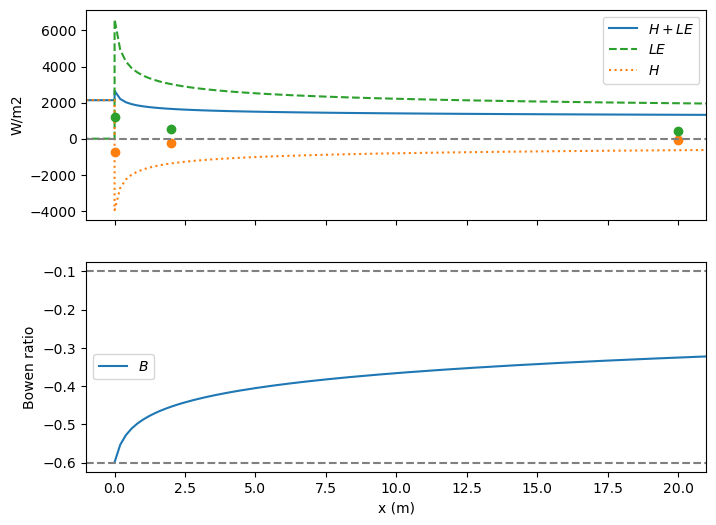

In [11]:


fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(xx, FluxTotal_,  c =  'C0', ls = '-', label = '$H + LE$')
ax.plot(xx, LE_Wm2,  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(xx, H_Wm2,  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(-1, 21)
ax.legend()
ax.plot(2, H_c2, 'C1o')
ax.plot(2, LE_c2, 'C2o')

ax.plot(20, H_c20, 'C1o')
ax.plot(20, LE_c20, 'C2o')

ax.plot(0, H_c0, 'C1o')
ax.plot(0, LE_c0, 'C2o')
ax.set_ylabel("W/m2")
ax.axhline(0, ls = '--', c = 'grey')

ax = axes[1]
ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')
plt.legend()

In [12]:
import re
from pathlib import Path
from typing import Union, Optional

import numpy as np
import pandas as pd

# Matches headers like: "T_x+18.5", "Rao_x-4.63", "T-x+1.15", etc.
_HEADER_PATTERN = re.compile(
    r'^\s*(?P<series>[A-Za-z]+)\s*[_\-]x\s*(?P<sign>[+\-])\s*(?P<xval>\d+(?:\.\d+)?)\s*$')

def parse_rao_wide_to_long(
    data: Union[str, Path, pd.DataFrame],
    start_row: int = 1) -> pd.DataFrame:
    """
    Parse a Rao-style wide digitized table into tidy long format.

    Parameters
    ----------
    data : str | Path | pd.DataFrame
        CSV path or a preloaded DataFrame with paired columns like:
        ['T_x+18.5', 'Unnamed: 1', 'T_x+1.15', 'Unnamed: 3', ...]
        First row contains 'X' (temperature) and 'Y' (height) labels per pair.
    start_row : int
        Row index where numeric data begin (default 1; row 0 = labels).

    Returns
    -------
    pd.DataFrame
        Columns: ['series', 'x', 'T', 'z'] where:
          - series: prefix from header (e.g., 'T', 'Rao')
          - x: horizontal distance (float), signed
          - T: temperature values (from the first-of-pair column)
          - z: vertical height values (from the second-of-pair column)
    """
    # Load input
    if isinstance(data, (str, Path)):
        df_raw = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df_raw = data.copy()
    else:
        raise TypeError("`data` must be a path or a pandas DataFrame.")

    rows = []
    cols = list(df_raw.columns)
    i = 0
    n = len(cols)

    while i < n:
        col_a = cols[i]
        m = _HEADER_PATTERN.match(str(col_a))
        if m:
            col_b = cols[i + 1] if (i + 1) < n else None

            series = m.group("series")
            sign   = m.group("sign")
            xval   = float(m.group("xval"))
            x = xval if sign == "+" else -xval

            T_vals = pd.to_numeric(df_raw[col_a].iloc[start_row:], errors="coerce").values
            if col_b is not None:
                z_vals = pd.to_numeric(df_raw[col_b].iloc[start_row:], errors="coerce").values
            else:
                z_vals = np.full_like(T_vals, np.nan, dtype=float)

            mlen = min(len(T_vals), len(z_vals))
            T_vals = T_vals[:mlen]
            z_vals = z_vals[:mlen]

            mask = ~(np.isnan(T_vals) & np.isnan(z_vals))
            T_vals = T_vals[mask]
            z_vals = z_vals[mask]

            for Tv, zv in zip(T_vals, z_vals):
                if not (np.isfinite(Tv) or np.isfinite(zv)):
                    continue
                rows.append({"series": series, "x": x, "T": Tv, "z": zv})

            i += 2  # advance past the pair
        else:
            i += 1  # skip non-matching column

    long_df = pd.DataFrame(rows)
    if not long_df.empty:
        long_df = long_df.sort_values(["series", "x", "z"], kind="mergesort").reset_index(drop=True)
    return long_df


# ---- Example usage (no printing, no saving, just DataFrames) ----
fig1_long = parse_rao_wide_to_long("../data/Rao_1974_Figure1.csv")
fig2_long = parse_rao_wide_to_long("../data/Rao_1974_Figure2.csv")



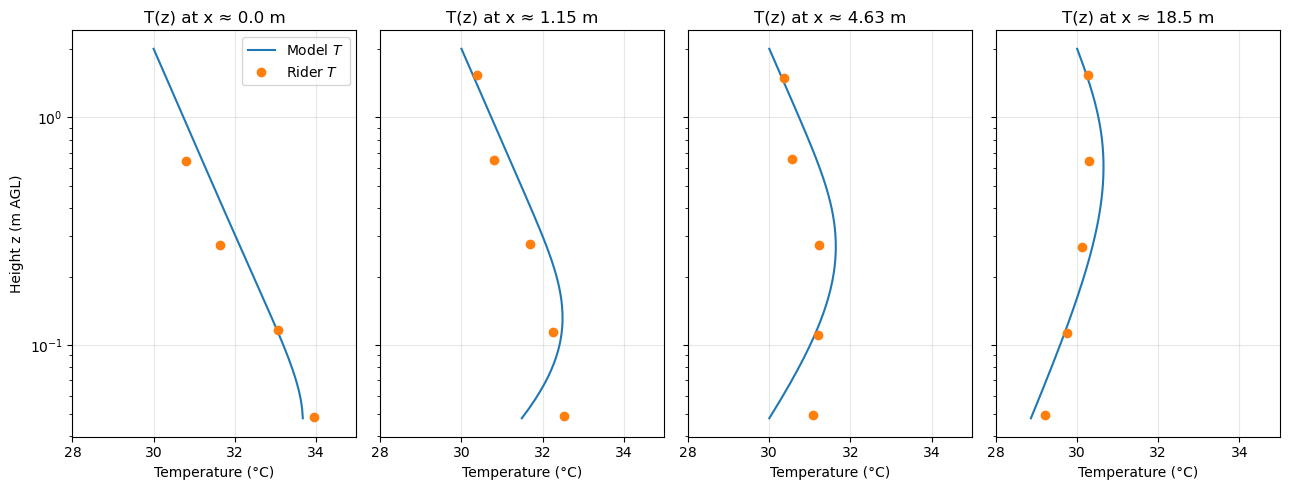

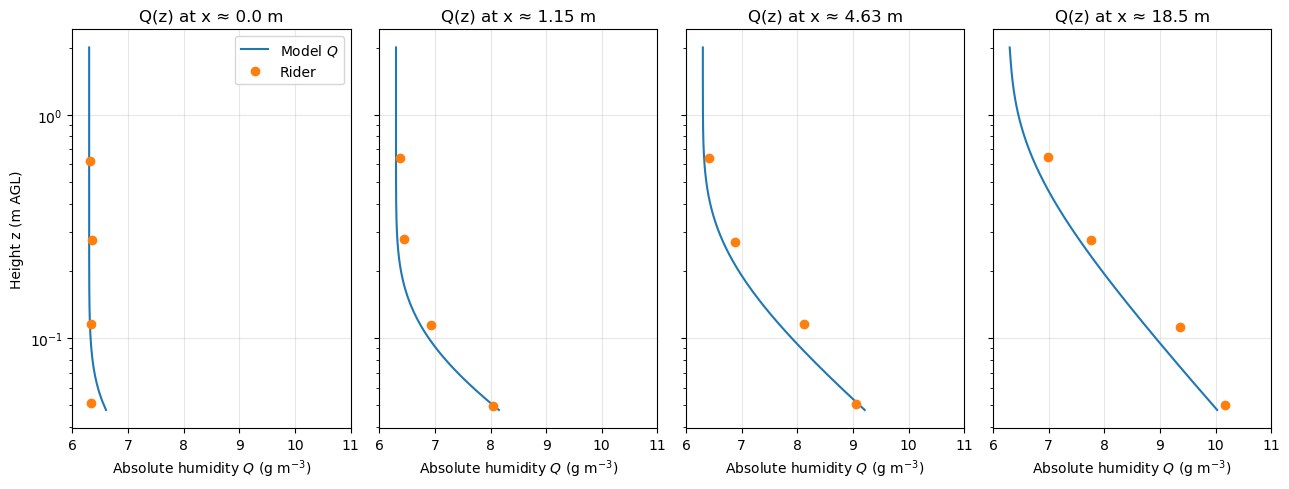

In [13]:
LOG_Y = True

# --------- T profiles (digitized Fig. 1 vs model T_uniform) ---------
x_panels_T = [0.0, 1.15, 4.63, 18.5]

fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)

ind0 = np.where(p.z>0.04)[0][0]
for ax, x_plot in zip(axes, x_panels_T):
    # nearest model x to desired location
    ind = np.argmin(np.abs(p.x - x_plot))
    
    # model profile
    ax.plot(T_uniform[ind][ind0:], p.z[ind0:] + p.d_c, label="Model $T$")
    
    # Rider digitized profile
    d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
    ax.plot(d1["T"][:-1], d1["z"][:-1], "o", label="Rider $T$")
    
    ax.set_title(f"T(z) at x ≈ {x_plot} m")
    ax.set_xlabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)

# Only left-most panel gets y-label and legend
axes[0].set_ylabel("Height z (m AGL)")
axes[0].legend()

# Apply y-scale toggle
for ax in axes:
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.set_xlim(28, 35)
plt.tight_layout()


# --------- Q profiles (digitized Fig. 2 vs model Q_uniform) ---------
x_panels_Q = [0.0, 1.15, 4.63, 18.5]

fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)

for ax, x_plot in zip(axes, x_panels_Q):
    # nearest model x to desired location
    ind = np.argmin(np.abs(p.x - x_plot))
    
    # model profile
    ax.plot(Q_uniform[ind][ind0:], p.z[ind0:] + p.d_c, "-", label="Model $Q$")
    
    # Rider digitized profile (column "T" holds Q for Fig. 2)
    d1 = fig2_long.query(f"x == {x_plot} and series == 'E'")
    ax.plot(d1["T"][:-1], d1["z"][:-1], "o", label="Rider")
    
    ax.set_title(f"Q(z) at x ≈ {x_plot} m")
    ax.set_xlabel(r"Absolute humidity $Q$ (g m$^{-3}$)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Height z (m AGL)")
axes[0].legend()

for ax in axes:
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.set_xlim(6,11)
plt.tight_layout()



In [34]:
import numpy as np

def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    # sort by height just in case
    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


# x-locations to compare (same as plots: 0, 1.15, 4.63, 18.5 m)
x_locs = [0.0, 1.15, 4.63, 18.5]

rmse_T = []
rmse_Q = []

# ---------- T profiles RMSE ----------
for x_plot in x_locs:
    # nearest model x
    ind = np.argmin(np.abs(p.x - x_plot))

    model_z = p.z + p.d_c          # z AGL with zero-plane displacement
    model_T = T_uniform[ind]

    d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
    rider_z = d1["z"].values[:-1]  # same truncation as in plots
    rider_T = d1["T"].values[:-1]

    rmse_T.append(profile_rmse(model_T, model_z, rider_T, rider_z))

# ---------- Q profiles RMSE ----------
for x_plot in x_locs:
    ind = np.argmin(np.abs(p.x - x_plot))

    model_z = p.z + p.d_c          # same height definition as T comparison
    model_Q = Q_uniform[ind]

    d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
    rider_z = d2["z"].values[:-1]
    rider_Q = d2["T"].values[:-1]  # digitized Q stored in column "T"

    rmse_Q.append(profile_rmse(model_Q, model_z, rider_Q, rider_z))


# ---------- Pretty printing as simple “table” (no tabulate) ----------
print("Temperature RMSE (model vs Rider):")
header = "x (m)   " + "  ".join(f"{x:7.2f}" for x in x_locs)
row_T  = "RMSE_T  " + "  ".join(f"{v:7.3f}" for v in rmse_T)
print(header)
print(row_T)

print("\nAbsolute humidity RMSE (model vs Rider):")
header = "x (m)   " + "  ".join(f"{x:7.2f}" for x in x_locs)
row_Q  = "RMSE_Q  " + "  ".join(f"{v:7.3f}" for v in rmse_Q)
print(header)
print(row_Q)


Temperature RMSE (model vs Rider):
x (m)      0.00     1.15     4.63    18.50
RMSE_T    0.351    0.519    0.568    0.239

Absolute humidity RMSE (model vs Rider):
x (m)      0.00     1.15     4.63    18.50
RMSE_Q    0.112    0.117    0.252    0.367


In [35]:
# --- RMSE helper ---
def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    if len(rider_z) == 0 or len(rider_vals) == 0:
        return np.nan

    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


def compute_rmse_for_case(p: Params, T_uniform, Q_uniform,
                          x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Compute RMSE arrays for T and Q at the given x locations,
    using z + d_c as the model height coordinate.
    """
    rmse_T = []
    rmse_Q = []

    z_model = p.z + p.d_c  # AGL, consistent with your plots

    for x_plot in x_locs:
        ix = np.argmin(np.abs(p.x - x_plot))

        # --- Temperature RMSE ---
        d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
        rider_z_T = d1["z"].values[:-1]
        rider_T   = d1["T"].values[:-1]
        model_T   = T_uniform[ix, :]

        rmse_T.append(profile_rmse(model_T, z_model, rider_T, rider_z_T))

        # --- Absolute humidity RMSE ---
        d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
        rider_z_Q = d2["z"].values[:-1]
        rider_Q   = d2["T"].values[:-1]   # Q digitized into column "T"
        model_Q   = Q_uniform[ix, :]

        rmse_Q.append(profile_rmse(model_Q, z_model, rider_Q, rider_z_Q))

    return np.array(rmse_T), np.array(rmse_Q)


# --------------------------------------------------------------------
# 1D sweep over ustar_f only (with tunable lm_zshift)
# --------------------------------------------------------------------
def sweep_ustar_f(ustar_f_values, shear_ratio: float = 1.0,
                  x_locs=(0.0, 1.15, 4.63, 18.5),
                  lm_zshift: float = 0.005):
    """
    For each ustar_f:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T, df_Q : pandas.DataFrame
        index  = ustar_f
        cols   = x-locations + 'mean'
    """
    rmse_T_all = []
    rmse_Q_all = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        p = Params(
            ustar_f=ustar_f,
            ustar_c=ustar_c,
            lm_option='kz',
            lm_zshift=lm_zshift,
            avail_ratio=1.2,
            Hmax=2.0,
            le_factor=1.2,
            dz=0.005,
            dx=0.1,
        )

        # radiation + BC updates
        p.solve_surface_radiation_inplace(fix="alpha_c")
        p.update_surface_BCs_from_zom()
        p.update_surface_BCs_from_reference()

        # solve fields
        T_uniform, _ = uniform_T(p)
        Q_uniform, _ = uniform_Q(p)

        rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

        rmse_T_all.append(rmse_T)
        rmse_Q_all.append(rmse_Q)

    rmse_T_all = np.array(rmse_T_all)
    rmse_Q_all = np.array(rmse_Q_all)

    x_cols = [f"x={float(x):.2f} m" for x in x_locs]

    df_T = pd.DataFrame(rmse_T_all, index=ustar_f_values, columns=x_cols)
    df_T.index.name = "ustar_f"
    df_T["mean"] = df_T.mean(axis=1)   # mean over x for each ustar_f

    df_Q = pd.DataFrame(rmse_Q_all, index=ustar_f_values, columns=x_cols)
    df_Q.index.name = "ustar_f"
    df_Q["mean"] = df_Q.mean(axis=1)

    return df_T, df_Q


# --------------------------------------------------------------------
# 3D gridded sweep over (ustar_f, zom_c, lm_zshift)
# --------------------------------------------------------------------
def sweep_ustar_f_zom_c_lmshift(ustar_f_values, zom_c_values, lm_zshift_values,
                                shear_ratio: float = 1.0,
                                x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Gridded sweep over ustar_f, zom_c, and lm_zshift.

    For each (ustar_f, zom_c, lm_zshift) triplet:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T_grid, df_Q_grid : pandas.DataFrame
        index  = MultiIndex[ustar_f, zom_c, lm_zshift]
        cols   = x-locations + 'mean'
    """
    rows_T = []
    rows_Q = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        for zom_c in zom_c_values:
            for lm_zshift in lm_zshift_values:

                p = Params(
                    ustar_f=ustar_f,
                    ustar_c=ustar_c,
                    zom_c=zom_c,
                    lm_option='kz',
                    lm_zshift=lm_zshift,
                    avail_ratio=1.2,
                    Hmax=2.0,
                    le_factor=1.2,
                    dz=0.005,
                    dx=0.2,
                )

                p.solve_surface_radiation_inplace(fix="alpha_c")
                p.update_surface_BCs_from_zom()
                p.update_surface_BCs_from_reference()

                T_uniform, _ = uniform_T(p)
                Q_uniform, _ = uniform_Q(p)

                rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

                x_cols = [f"x={float(x):.2f} m" for x in x_locs]

                row_T = {"ustar_f": ustar_f, "zom_c": zom_c, "lm_zshift": lm_zshift}
                row_Q = {"ustar_f": ustar_f, "zom_c": zom_c, "lm_zshift": lm_zshift}

                for xc, rt, rq in zip(x_cols, rmse_T, rmse_Q):
                    row_T[xc] = rt
                    row_Q[xc] = rq

                rows_T.append(row_T)
                rows_Q.append(row_Q)

    df_T_grid = pd.DataFrame(rows_T).set_index(["ustar_f", "zom_c", "lm_zshift"])
    df_Q_grid = pd.DataFrame(rows_Q).set_index(["ustar_f", "zom_c", "lm_zshift"])

    # add mean-over-x column for each (ustar_f, zom_c, lm_zshift)
    x_cols = [c for c in df_T_grid.columns if c.startswith("x=")]
    df_T_grid["mean"] = df_T_grid[x_cols].mean(axis=1)
    df_Q_grid["mean"] = df_Q_grid[x_cols].mean(axis=1)

    return df_T_grid, df_Q_grid


ustar_vals   = [ 0.3, 0.5, 0.6, 0.7, 0.8]
zom_vals     = [2e-4, 5e-4, 1e-3]
lm_shifts    = [0.0, 0.0025, 0.005, 0.01]

df_T_grid, df_Q_grid = sweep_ustar_f_zom_c_lmshift(
    ustar_vals, zom_vals, lm_shifts
)

# e.g. minimum mean T-RMSE combo:
df_T_grid["mean"].idxmin(), df_T_grid["mean"].min()

((0.8, 0.0005, 0.0025), 0.3633567199975254)

In [17]:
df_T_grid.sort_values('mean').head(5)


x=0.00 m  x=1.15 m  x=4.63 m  x=18.50 m      mean
ustar_f zom_c  lm_zshift                                                   
0.8     0.0005 0.0025     0.405361  0.237880  0.309930   0.500256  0.363357
               0.0050     0.421765  0.313300  0.324972   0.402367  0.365601
        0.0002 0.0050     0.411945  0.231006  0.327962   0.501765  0.368169
        0.0010 0.0000     0.389092  0.233333  0.301176   0.556990  0.370148
               0.0025     0.415658  0.338519  0.311229   0.420829  0.371559

In [18]:
df_Q_grid.sort_values('mean').head(5)

,,,x=0.00 m,x=1.15 m,x=4.63 m,x=18.50 m,mean
ustar_f,zom_c,lm_zshift,,,,,
0.6,0.0002,0.0100,0.096599,0.123874,0.253464,0.212955,0.171723
0.5,0.0010,0.0025,0.099184,0.126148,0.257468,0.263402,0.186551
0.6,0.0005,0.0100,0.109298,0.142297,0.275302,0.224304,0.187800
0.5,0.0002,0.0050,0.072513,0.141569,0.289825,0.289140,0.198262
0.6,0.0010,0.0100,0.168678,0.213575,0.262697,0.194237,0.209797


In [19]:
import numpy as np
import pandas as pd

# --- RMSE helper (unchanged) ---
def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)

    if len(rider_z) == 0 or len(rider_vals) == 0:
        return np.nan

    order = np.argsort(model_z)
    mz = model_z[order]
    mp = model_profile[order]

    mp_at_rz = np.interp(rider_z, mz, mp)
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


def compute_rmse_for_case(p: Params, T_uniform, Q_uniform,
                          x_locs=(0.0, 1.15, 4.63, 18.5)):
    """
    Compute RMSE arrays for T and Q at the given x locations,
    using z + d_c as the model height coordinate.
    """
    rmse_T = []
    rmse_Q = []

    z_model = p.z + p.d_c  # AGL, consistent with your plots

    for x_plot in x_locs:
        ix = np.argmin(np.abs(p.x - x_plot))

        # --- Temperature RMSE ---
        d1 = fig1_long.query(f"x == {x_plot} and series == 'T'")
        rider_z_T = d1["z"].values[:-1]
        rider_T   = d1["T"].values[:-1]
        model_T   = T_uniform[ix, :]

        rmse_T.append(profile_rmse(model_T, z_model, rider_T, rider_z_T))

        # --- Absolute humidity RMSE ---
        d2 = fig2_long.query(f"x == {x_plot} and series == 'E'")
        rider_z_Q = d2["z"].values[:-1]
        rider_Q   = d2["T"].values[:-1]   # Q digitized into column "T"
        model_Q   = Q_uniform[ix, :]

        rmse_Q.append(profile_rmse(model_Q, z_model, rider_Q, rider_z_Q))

    return np.array(rmse_T), np.array(rmse_Q)


# --------------------------------------------------------------------
# 1D sweep over ustar_f only (with tunable lm_zshift, avail_ratio, le_factor)
# --------------------------------------------------------------------
def sweep_ustar_f(
    ustar_f_values,
    shear_ratio: float = 1.0,
    x_locs=(0.0, 1.15, 4.63, 18.5),
    lm_zshift: float = 0.005,
    avail_ratio: float = 1.2,
    le_factor: float = 1.2,
):
    """
    For each ustar_f:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T, df_Q : pandas.DataFrame
        index  = ustar_f
        cols   = x-locations + 'mean'
    """
    rmse_T_all = []
    rmse_Q_all = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        p = Params(
            ustar_f=ustar_f,
            ustar_c=ustar_c,
            lm_option='kz',
            lm_zshift=lm_zshift,
            avail_ratio=avail_ratio,
            le_factor=le_factor,
            Hmax=2.0,
            dz=0.005,
            dx=0.1,
        )

        # radiation + BC updates
        p.solve_surface_radiation_inplace(fix="alpha_c")
        p.update_surface_BCs_from_zom()
        p.update_surface_BCs_from_reference()

        # solve fields
        T_uniform, _ = uniform_T(p)
        Q_uniform, _ = uniform_Q(p)

        rmse_T, rmse_Q = compute_rmse_for_case(p, T_uniform, Q_uniform, x_locs)

        rmse_T_all.append(rmse_T)
        rmse_Q_all.append(rmse_Q)

    rmse_T_all = np.array(rmse_T_all)
    rmse_Q_all = np.array(rmse_Q_all)

    x_cols = [f"x={float(x):.2f} m" for x in x_locs]

    df_T = pd.DataFrame(rmse_T_all, index=ustar_f_values, columns=x_cols)
    df_T.index.name = "ustar_f"
    df_T["mean"] = df_T.mean(axis=1)

    df_Q = pd.DataFrame(rmse_Q_all, index=ustar_f_values, columns=x_cols)
    df_Q.index.name = "ustar_f"
    df_Q["mean"] = df_Q.mean(axis=1)

    return df_T, df_Q


# --------------------------------------------------------------------
# 5D gridded sweep over (ustar_f, zom_c, lm_zshift, avail_ratio, le_factor)
# --------------------------------------------------------------------
def sweep_ustar_f_zom_c_lmshift_le(
    ustar_f_values,
    zom_c_values,
    lm_zshift_values,
    avail_ratio_values,
    le_factor_values,
    shear_ratio: float = 1.0,
    x_locs=(0.0, 1.15, 4.63, 18.5),
):
    """
    Gridded sweep over ustar_f, zom_c, lm_zshift, avail_ratio, and le_factor.

    For each combination:
      * build Params
      * run radiation + BC updates
      * solve uniform_T / uniform_Q
      * compute RMSE vs Rider at x_locs

    Returns
    -------
    df_T_grid, df_Q_grid : pandas.DataFrame
        index  = MultiIndex[ustar_f, zom_c, lm_zshift, avail_ratio, le_factor]
        cols   = x-locations + 'mean'
    """
    rows_T = []
    rows_Q = []

    for ustar_f in ustar_f_values:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        for zom_c in zom_c_values:
            for lm_zshift in lm_zshift_values:
                for avail_ratio in avail_ratio_values:
                    for le_factor in le_factor_values:

                        p = Params(
                            ustar_f=ustar_f,
                            ustar_c=ustar_c,
                            zom_c=zom_c,
                            lm_option='kz',
                            lm_zshift=lm_zshift,
                            avail_ratio=avail_ratio,
                            le_factor=le_factor,
                            Hmax=2.0,
                            dz=0.005,
                            dx=0.2,   # your choice from previous snippet
                        )

                        p.solve_surface_radiation_inplace(fix="alpha_c")
                        p.update_surface_BCs_from_zom()
                        p.update_surface_BCs_from_reference()

                        T_uniform, _ = uniform_T(p)
                        Q_uniform, _ = uniform_Q(p)

                        rmse_T, rmse_Q = compute_rmse_for_case(
                            p, T_uniform, Q_uniform, x_locs
                        )

                        x_cols = [f"x={float(x):.2f} m" for x in x_locs]

                        row_T = {
                            "ustar_f": ustar_f,
                            "zom_c": zom_c,
                            "lm_zshift": lm_zshift,
                            "avail_ratio": avail_ratio,
                            "le_factor": le_factor,
                        }
                        row_Q = row_T.copy()

                        for xc, rt, rq in zip(x_cols, rmse_T, rmse_Q):
                            row_T[xc] = rt
                            row_Q[xc] = rq

                        rows_T.append(row_T)
                        rows_Q.append(row_Q)

    df_T_grid = pd.DataFrame(rows_T).set_index(
        ["ustar_f", "zom_c", "lm_zshift", "avail_ratio", "le_factor"]
    )
    df_Q_grid = pd.DataFrame(rows_Q).set_index(
        ["ustar_f", "zom_c", "lm_zshift", "avail_ratio", "le_factor"]
    )

    x_cols = [c for c in df_T_grid.columns if c.startswith("x=")]
    df_T_grid["mean"] = df_T_grid[x_cols].mean(axis=1)
    df_Q_grid["mean"] = df_Q_grid[x_cols].mean(axis=1)

    return df_T_grid, df_Q_grid

ustar_vals = [0.5, 0.6, 0.7, 0.8, 0.9]
zom_vals   = [2e-4, 5e-4, 1e-3]
lm_shifts  = [0.0, 0.001, 0.0025, 0.005, 0.01]
avail_vals = [1.0, 1.1, 1.2, 1.3]
le_vals    = [0.8, 0.9, 1.0, 1.2, 1.3]

df_T_grid, df_Q_grid = sweep_ustar_f_zom_c_lmshift_le(
    ustar_vals, zom_vals, lm_shifts, avail_vals, le_vals
)

# Best mean T-fit combo:
df_T_grid["mean"].idxmin(), df_T_grid["mean"].min()

((0.8, 0.0005, 0.001, 1.3, 1.3), 0.3309848614606319)

In [38]:
df_T_grid.sort_values('mean').query("mean < 0.37").head()

x=0.00 m  x=1.15 m  x=4.63 m  x=18.50 m      mean
ustar_f zom_c  lm_zshift                                                   
0.8     0.0005 0.0025     0.405361  0.237880  0.309930   0.500256  0.363357
               0.0050     0.421765  0.313300  0.324972   0.402367  0.365601
        0.0002 0.0050     0.411945  0.231006  0.327962   0.501765  0.368169

In [37]:
df_Q_grid.sort_values('x=18.50 m').query("mean < 0.2").head()

x=0.00 m  x=1.15 m  x=4.63 m  x=18.50 m      mean
ustar_f zom_c  lm_zshift                                                   
0.6     0.0002 0.0100     0.096599  0.123874  0.253464   0.212955  0.171723
        0.0005 0.0100     0.109298  0.142297  0.275302   0.224304  0.187800
0.5     0.0010 0.0025     0.099184  0.126148  0.257468   0.263402  0.186551
        0.0002 0.0050     0.072513  0.141569  0.289825   0.289140  0.198262

In [22]:
df_Q_grid.head()

x=0.00 m  x=1.15 m  x=4.63 m  \
ustar_f zom_c  lm_zshift avail_ratio le_factor                                 
0.5     0.0002 0.0       1.0         0.8        0.031571  0.658406  1.042772   
                                     0.9        0.031666  0.624468  0.965933   
                                     1.0        0.031941  0.590657  0.889822   
                                     1.2        0.033013  0.523511  0.740684   
                                     1.3        0.033792  0.490241  0.668345   

                                                x=18.50 m      mean  
ustar_f zom_c  lm_zshift avail_ratio le_factor                       
0.5     0.0002 0.0       1.0         0.8         1.497710  0.807615  
                                     0.9         1.361832  0.745975  
                                     1.0         1.226613  0.684758  
                                     1.2         0.959269  0.564119  
                                     1.3         0.828143  0.505130

ValueError: x and y must have same first dimension, but have shapes (599,) and (800,)

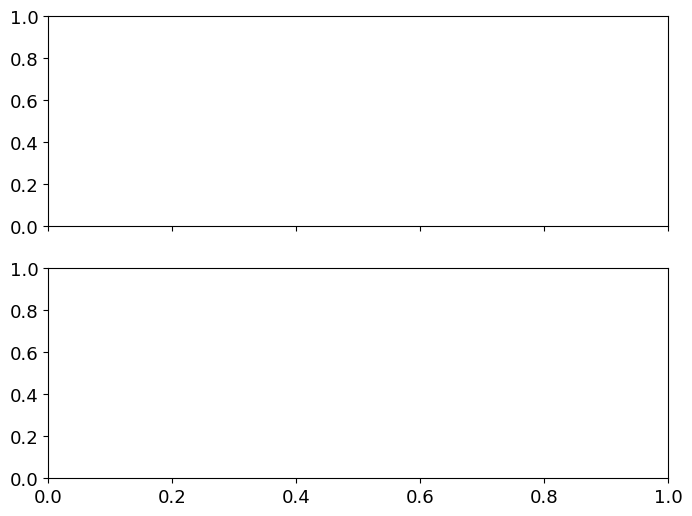

In [39]:

fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx =  np.concatenate([-np.flip(x),x])
# FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

level = 0
Q = np.concatenate([ Q_up[level]*np.ones_like(x), Q_uniform[:, level]])
T = np.concatenate([ T_up[level]*np.ones_like(x), T_uniform[:, level]])

ax.plot(xx[1:], (Q[1:]),  ls = '--', c =  'C2',  label = "$Q$")
ax.plot(xx[1:], (T[1:]),  ls = ':', c =  'C1',  label = "$T$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

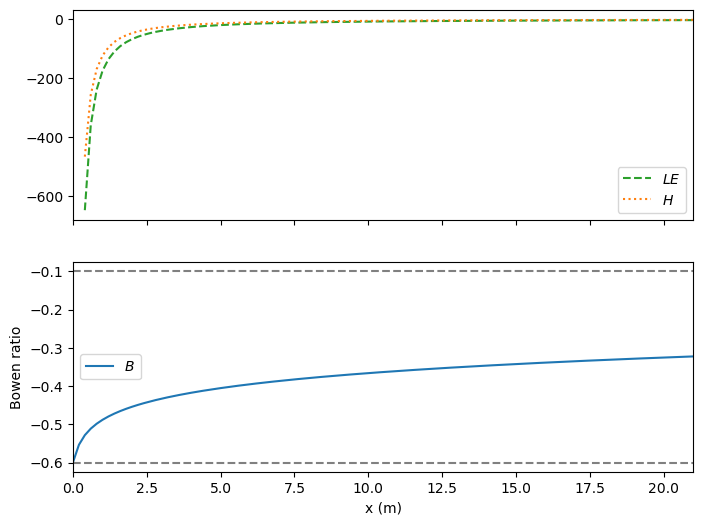

In [25]:
level = 0
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(p.x[2:], np.diff(LE_uniform_Wm2[1:,level]),  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(p.x[2:], - np.diff(H_uniform_Wm2[1:, level]),  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

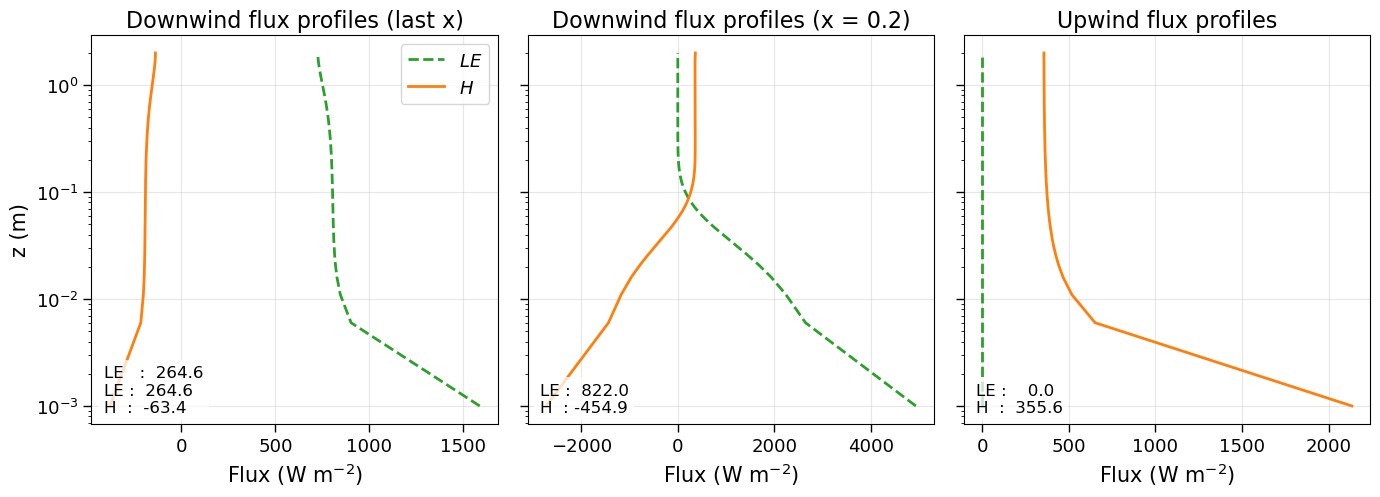

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- gradient-based flux checks (using two-point logs) ----------------
# Downwind (last x)
le_last = p.ustar_c * p.k * (Q_uniform[-1, 1] - Q_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_last  = p.ustar_c * p.k * (T_uniform[-1, 1] - T_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Downwind (near-upstream, x index 1)
le_x1 = p.ustar_c * p.k * (Q_uniform[1, 1] - Q_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_x1  = p.ustar_c * p.k * (T_uniform[1, 1] - T_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Upwind
le_up = p.ustar_f * p.k * (Q_up[1] - Q_up[2]) / np.log(p.z[2] / p.z[1]) * Lv_g
h_up  = p.ustar_f * p.k * (T_up[1] - T_up[0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# ---------------- figure with 3 subplots (larger fonts, consistent styles across subplots) ----------------
plt.rcParams.update({
    "font.size": 14,                # base font size
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True)

# Common styles (do not change between subplots)
style_LE = dict(color='C2', linestyle='--', linewidth=2.0, label='$LE$')
style_H  = dict(color='C1', linestyle='-',  linewidth=2.0, label='$H$')

# Panel 1: Downwind (last x) vertical profiles
ax = axes[0]
ax.plot(LE_uniform_Wm2[-1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[-1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (last x)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.set_ylabel("z (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(length=6, width=1)

txt1 = (f"LE   : {le_last:6.1f}\n"
        f"LE : {le_last:6.1f}\n"
        f"H  : {h_last:6.1f}")
ax.text(0.03, 0.03, txt1, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 2: Downwind (x=1) vertical profiles
ax = axes[1]
ax.plot(LE_uniform_Wm2[1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (x = 0.2)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt2 = (f"LE : {le_x1:6.1f}\n"
        f"H  : {h_x1:6.1f}")
ax.text(0.03, 0.03, txt2, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 3: Upwind vertical profiles
ax = axes[2]
ax.plot(LE_upwind_Wm2, p.z, **style_LE)
ax.plot(H_upwind_Wm2,  p.z, **style_H)
ax.set_title("Upwind flux profiles")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt3 = (f"LE : {le_up:6.1f}\n"
        f"H  : {h_up:6.1f}")
ax.text(0.03, 0.03, txt3, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.tight_layout()

for ax in axes:
    ax.set_yscale('log')



In [27]:
# Upwind checks

H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

print("H_f (Params):       ", p.H_f)
print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 


# Downwind checks
# Lv_g = 2430.0  # J g^-1
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

print("\nLE_c (Params):      ", p.LE_c)
print("LE_wall:             {0:.2f} ".format(LE_wall_Wm2))  


H_f (Params):        355.64
H_wall:              355.64

LE_c (Params):       601.0316
LE_wall:             601.03 


\begin{aligned}
\mathrm{SW}\,(1-\alpha_f) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_f \,\sigma_{SB}\, T_{sf}^{4} &= R_{n,f}, \\
\mathrm{SW}\,(1-\alpha_c) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_c \,\sigma_{SB}\, T_{sc}^{4} &= R_{n,c}, \\
T_{sf} - T_a &= \frac{1}{k\,u_{*f}}\,
  \frac{H_f}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
T_{sc} - T_a &= \frac{1}{k\,u_{*c}}\,
  \frac{H_c}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
Q_c - Q_a &= \frac{1}{k\,u_{*c}}\,
  \frac{\mathrm{LE}_c}{L_v}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
R_{n,c} - G &= \mathrm{LE}_c + H_c .
\end{aligned}

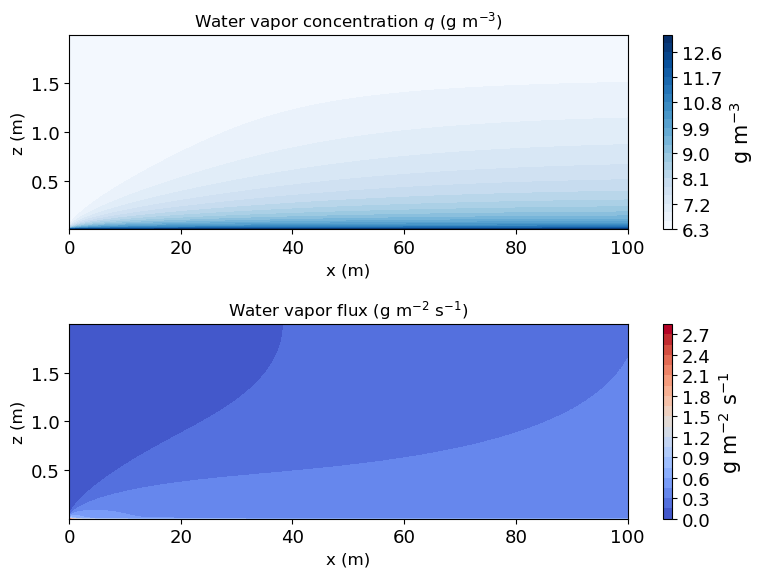

In [28]:
z = p.z
x = p.x

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
nz = Q_uniform.shape[1]
plt.contourf(x, z[:nz], (Q_uniform.T), 25, cmap='Blues',  vmax = p.Q_c, vmin =p.Q_a)
plt.colorbar(label='g m$^{-3}$')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[:nz], FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = FluxQ_uniform.max())
plt.colorbar(label='g m$^{-2}$ s$^{-1}$') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



In [29]:

level = 1
# rough estimate at level height z:
z_eff = z[level] - p.h_c*2/3
lm    = p.k * z_eff  
K     = lm * ustar_c
U = (p.ustar_f / p.k) * np.log(z / p.zom_c) 
Lrec  = U[level] * z_eff / (p.k * ustar_c)   

In [30]:
Q_uniform.shape, p.z.shape

((501, 400), (400,))

[-1648.16507539 -1028.19740507  -776.76675308  -622.3915387 ]
SH(x) ≈ -630.41 + (-1017.75) * exp(-x/0.90)
LH(x) ≈ 1503.65 + (1449.61) * exp(-x/0.90)


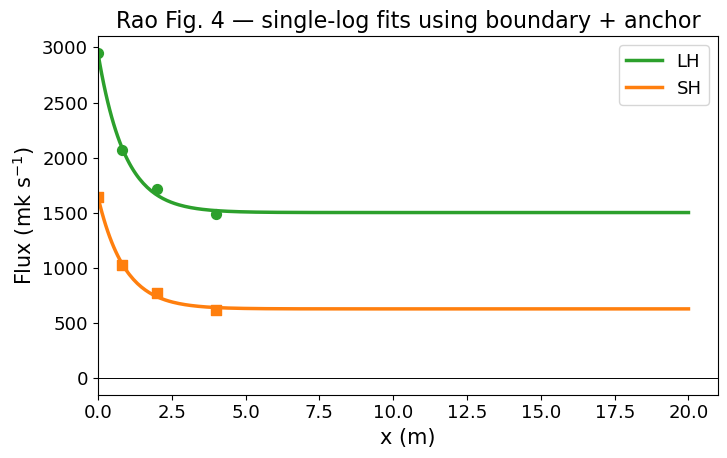

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.optimize import curve_fit
 
    
# -----------------  boundary + anchor points (edit if you read different values) -----------------
# x in meters; y in the figure’s flux units (“mk s^-1”)
x0, ySH0, yLH0 = 0.1,  -0.60,  1.00   # start (x=0)
xA, ySHA, yLHA = 2.0,  -0.20,  0.45   # 2 m
xB, ySHB, yLHB = 6.0,  -0.10,  0.4    # 6 m
xF, ySHF, yLHF = 20.0, -0.05,  0.36   # far downstream

# level = 1

x0, ySH0, yLH0 = p.x[0],  H_uniform_Wm2[0, level],  LE_uniform_Wm2[0, level]   # start (x=0)
xA, ySHA, yLHA = p.x[4], H_uniform_Wm2[4, level],  LE_uniform_Wm2[4, level]   # start (x=0)
xB, ySHB, yLHB = p.x[10], H_uniform_Wm2[10, level],  LE_uniform_Wm2[10, level]   # start (x=0)
xF, ySHF, yLHF = p.x[20], H_uniform_Wm2[20, level],  LE_uniform_Wm2[20, level]   # start (x=0)


# Choose a small positive shift so ln(x + x_shift) is defined at x=0.
x_shift = 0.001

x_pts   = np.array([x0, xA, xB, xF], float)
ySH_pts = np.array([ySH0, ySHA, ySHB, ySHF], float)
yLH_pts = np.array([yLH0, yLHA, yLHB, yLHF], float)

print(ySH_pts, )
def exp1(x, y_inf, L):
    # one-exponential with y0 fixed by the first point
    y0 = ySH0_or_yLH0 
    return y_inf + (y0 - y_inf) * np.exp(-x / L)

# Fit SH
ySH0_or_yLH0 = ySH0
p0_SH = (ySHF, 2.0)                              # initial guess: asymptote ~ far point
par_SH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, ySH_pts, p0=p0_SH, maxfev=10000)
ySH_inf, L_SH = par_SH

# Fit LH
ySH0_or_yLH0 = yLH0
p0_LH = (yLHF, 2.0)
par_LH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, yLH_pts, p0=p0_LH, maxfev=10000)
yLH_inf, L_LH = par_LH

# Evaluate
x = np.linspace(0, 20, 300)
SH_fit = ySH_inf + (ySH0 - ySH_inf)*np.exp(-x/L_SH)
LH_fit = yLH_inf + (yLH0 - yLH_inf)*np.exp(-x/L_LH)

SH_range = ySH0 - ySH_inf 
LH_range = yLH0 - yLH_inf
print(f"SH(x) ≈ {ySH_inf:.2f} + ({SH_range:.2f}) * exp(-x/{L_SH:.2f})")
print(f"LH(x) ≈ {yLH_inf:.2f} + ({LH_range:.2f}) * exp(-x/{L_LH:.2f})")


# ----------------- 4) plot -----------------
plt.figure(figsize=(7.5, 4.8))
plt.plot(x,  LH_fit,  'C2', lw=2.5, label='LH')
plt.plot(x,  -SH_fit,  'C1', lw=2.5, label='SH')
plt.scatter(x_pts, yLH_pts, c='C2', s=50, marker='o', label='')
plt.scatter(x_pts, -ySH_pts, c='C1', s=50, marker='s', label='')
plt.axhline(0, color='k', lw=0.7)
plt.xlim(0, 21); 
# plt.ylim(-0.65, 1.1)
plt.xlabel('x (m)')
plt.ylabel('Flux (mk s$^{-1}$)')
plt.title('Rao Fig. 4 — single-log fits using boundary + anchor')
plt.legend()
plt.tight_layout()
plt.show()




### Appendix

In [32]:
# density depends on air temperature
import numpy as np

# --- constants ---
cp  = 1005.0          # J kg^-1 K^-1  (specific heat at constant pressure)
R_d = 287.05          # J kg^-1 K^-1  (gas constant for dry air)
p_Pa = 101325.0       # Pa (set your measured station pressure if available)

def air_density(T_K, p_Pa=101325.0, q_kgkg=None):
    """
    Air density [kg m^-3] from temperature (K), pressure (Pa), and optional specific humidity q (kg/kg).
    Uses virtual temperature: T_v = T*(1 + 0.61 q) if q is provided.
    """
    if q_kgkg is not None:
        T_v = T_K * (1.0 + 0.61*q_kgkg)
    else:
        T_v = T_K
    return p_Pa / (R_d * T_v)

# If you already have ambient humidity as Q_a in g/kg, use it for moist-air density.
# Otherwise we'll compute a dry-air density.
try:
    q_a = Q_a / 1000.0   # g/kg -> kg/kg
except NameError:
    q_a = None

T_a = 30
rho = air_density(T_a, p_Pa=p_Pa, q_kgkg=q_a)

# --- your original variables ---
zo = p.zom_f
ustar_f = 0.15
ustar_c = 0.15
k = p.k

# stability-neutral bulk transfer (ensure z_h > zo)
L = np.log(p.z[-1] / zo)      # dimensionless

# Use rho*cp instead of 1005*1.2
T_sc = T_a + (p.H_c/(rho*cp)) * (1.0/(k*ustar_c)) * L
print(T_sc - 273.15)

T_sf = T_a + (p.H_f/(rho*cp)) * (1.0/(k*ustar_f)) * L
print(T_sf - 273.15)

print(T_sf - T_sc)


-244.77099575822302
-238.99360061994085
5.777395138282177
